In [56]:
# import libraries
import seaborn as sns
import matplotlib.pyplot as plt
from sklearn.datasets import load_wine
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, ConfusionMatrixDisplay, confusion_matrix, accuracy_score
from sklearn.tree import plot_tree

In [58]:
# data loading
data = load_wine()
X, y = data.data, data.target
feature_names = data.feature_names
class_names = data.target_names

In [59]:
# Train_test split
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.30, random_state=42, stratify=y
)

In [60]:
rf = RandomForestClassifier(n_estimators=50,  # number of trees
                            max_depth=None,  # daraxt chuqurligi
                            )

rf.fit(X_train, y_train)

RandomForestClassifier(n_estimators=50)

In [61]:
# Evaluation
y_pred = rf.predict(X_test)
print(f"Accuracy: {accuracy_score(y_test, y_pred):.3f}")
print(classification_report(y_test, y_pred, target_names=class_names))

Accuracy: 0.981
              precision    recall  f1-score   support

     class_0       1.00      1.00      1.00        18
     class_1       1.00      0.95      0.98        21
     class_2       0.94      1.00      0.97        15

    accuracy                           0.98        54
   macro avg       0.98      0.98      0.98        54
weighted avg       0.98      0.98      0.98        54



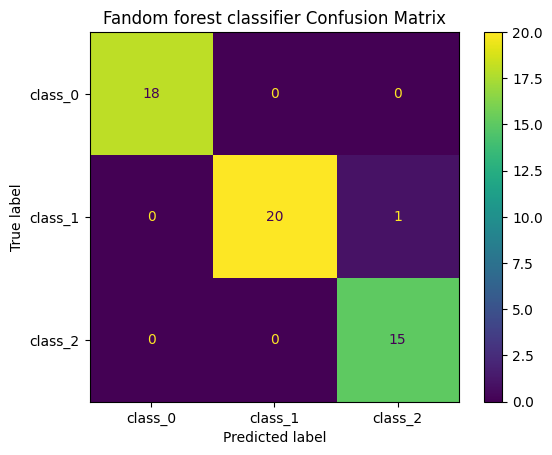

In [62]:
# Confusion matrix
cm = confusion_matrix(y_test, y_pred)
disp = ConfusionMatrixDisplay(cm, display_labels=class_names)
disp.plot()
plt.title('Fandom forest classifier Confusion Matrix')
plt.show()

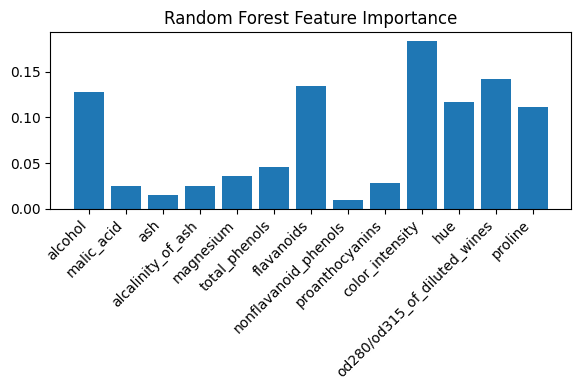

In [63]:
# Feature importance graph
plt.figure(figsize=(6, 4))
plt.bar(range(len(feature_names)), rf.feature_importances_)
plt.xticks(range(len(feature_names)), feature_names, rotation=45, ha='right')
plt.title('Random Forest Feature Importance')
plt.tight_layout()
plt.show()

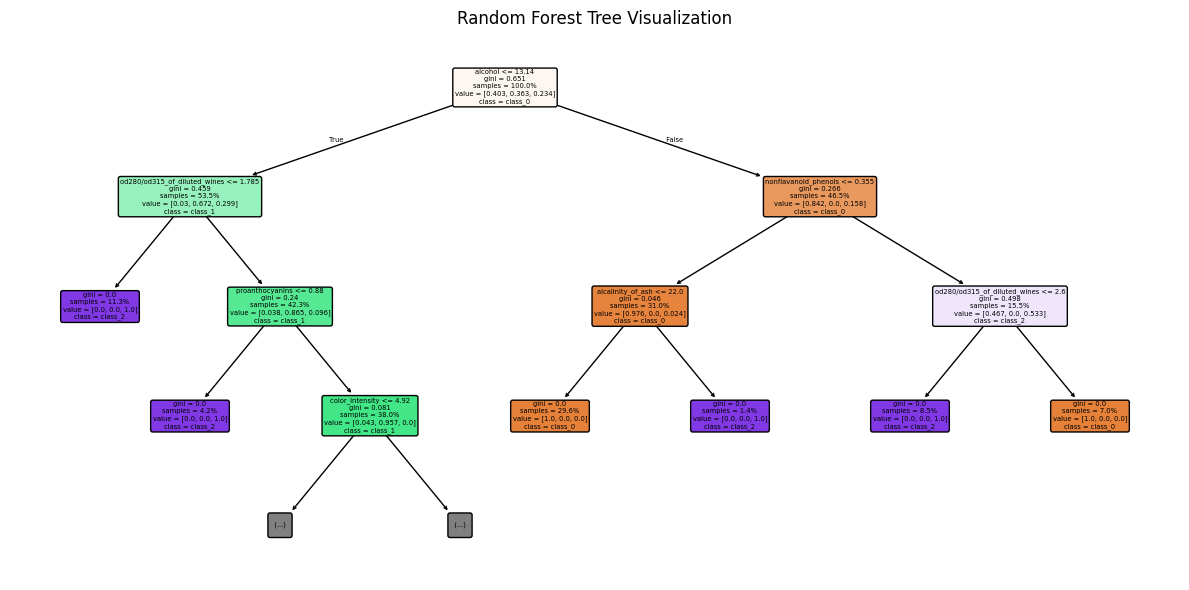

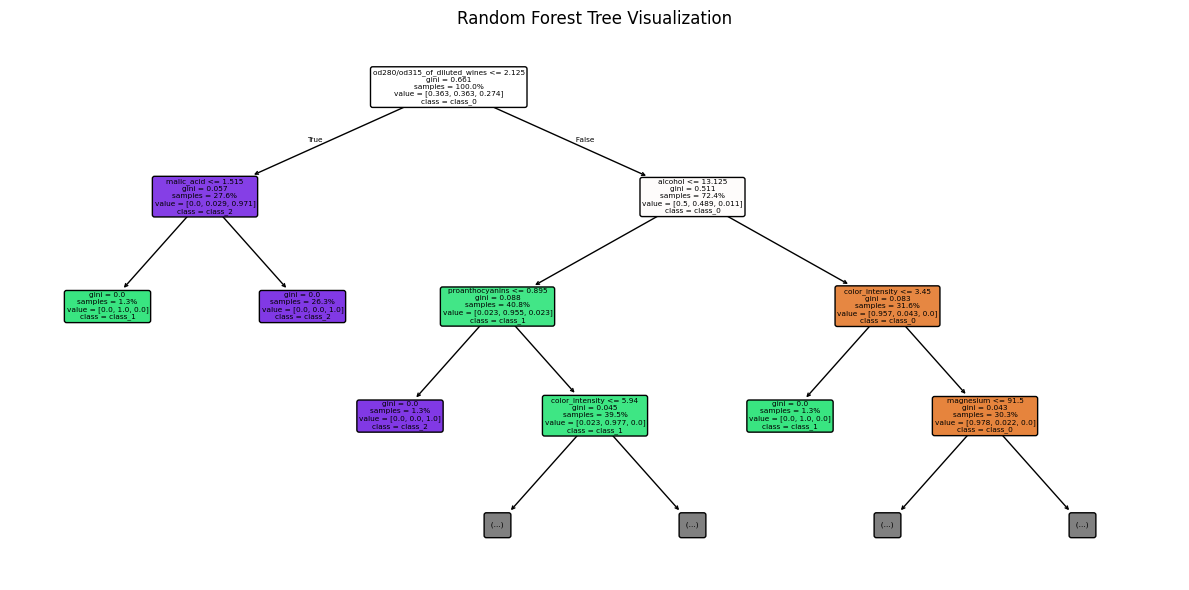

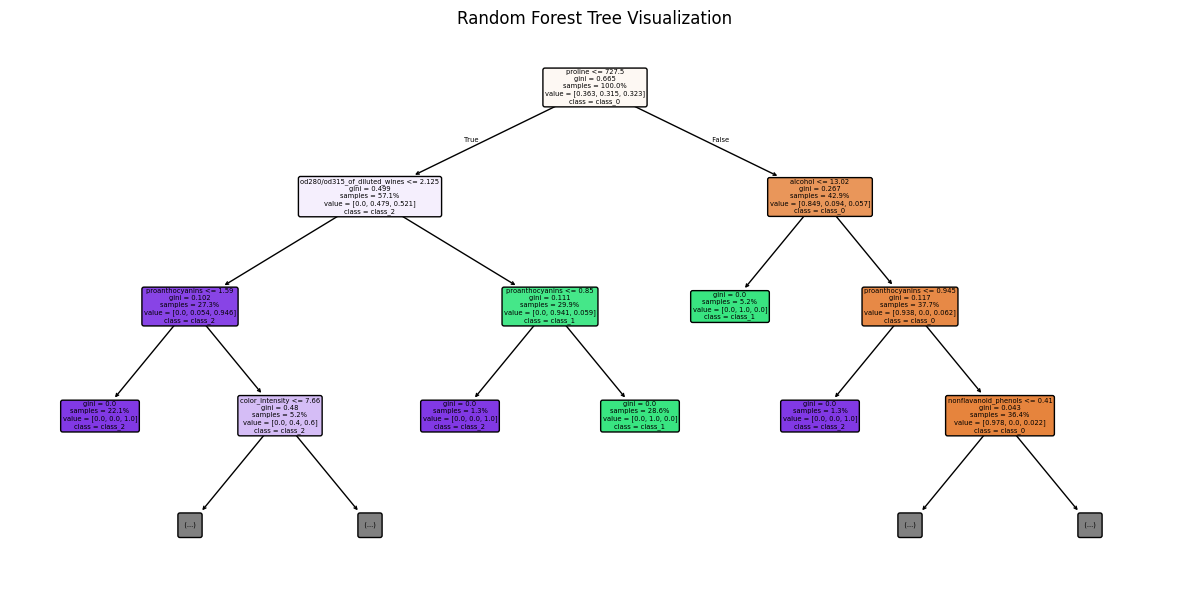

None


In [65]:
# Trees visualization

def visualize_forest_trees(forest, feature_names=feature_names, class_names=class_names, n=3, max_depth=3):
  n = min(n, len(forest.estimators_))
  for i in range(n):
    estimator = forest.estimators_[i]
    plt.figure(figsize=(12, 6))
    plot_tree(
        estimator,
        feature_names=feature_names,
        class_names=class_names,
        filled = True,
        rounded = True,
        impurity = True,
        proportion = True,
        max_depth = max_depth
    )
    plt.title('Random Forest Tree Visualization')
    plt.tight_layout()
    plt.show()


print(visualize_forest_trees(rf))

#visualize_forest_trees(rf, feature_names, class_names, n=3, max_depth=3)